# 2D BEM Solver Test: Compressed Disk

Testing the BEM solver with mixed boundary conditions on a circular disk under compression.

# 2D Boundary Element Method (BEM) Solver for Elasticity

## Overview

This is a complete 2D BEM solver for linear elasticity problems with mixed boundary conditions. The solver is implemented in C++ for computational efficiency with Python bindings for ease of use in Jupyter notebooks and scientific workflows.

## Features

- **Mixed Boundary Conditions**: Handles both traction (Neumann) and displacement (Dirichlet) boundary conditions on different boundary patches
- **Kelvin Fundamental Solutions**: Uses the classical Kelvin fundamental solution for 2D elasticity
- **Single and Double Layer Potentials**: Implements both displacement (U) and traction (T) kernels
- **Plane Strain/Stress**: Supports both plane strain and plane stress formulations
- **Interior Point Evaluation**: Can compute displacements at arbitrary interior points after solving the boundary problem
- **Efficient Implementation**: C++ core with Eigen for linear algebra, achieving good performance

## Mathematical Formulation

### Governing Equations

The BEM formulation is based on the boundary integral equation:

```
c(ξ)u(ξ) + ∫_Γ T(ξ,x)u(x)dΓ = ∫_Γ U(ξ,x)t(x)dΓ
```

where:
- `u(x)` = displacement vector at boundary point x
- `t(x)` = traction vector at boundary point x
- `U(ξ,x)` = Kelvin displacement fundamental solution (Green's function)
- `T(ξ,x)` = Kelvin traction fundamental solution
- `c(ξ)` = free term (0.5 for smooth boundaries)

### Kelvin Fundamental Solutions

For 2D plane elasticity, the Kelvin fundamental solutions are:

**Displacement kernel (U_ij):**
```
U_ij = [1/(8πG(1-ν))] * [-(3-4ν)ln(r)δ_ij + r_i*r_j/r²]
```

**Traction kernel (T_ij):**
```
T_ij = -[1/(4π(1-ν)r)] * {(∂r/∂n)[(1-2ν)δ_ij + 2r_i*r_j/r²] - (1-2ν)(r_i*n_j - r_j*n_i)}
```

where:
- `r = |x - ξ|` is the distance between source and field points
- `G = E/[2(1+ν)]` is the shear modulus
- `δ_ij` is the Kronecker delta
- `n` is the outward normal vector

## Installation

### Prerequisites

- C++ compiler with C++14 support
- Eigen3 library (linear algebra)
- Python 3.x
- pybind11 (Python bindings)
- NumPy, Matplotlib (for visualization)

### Build Instructions

```bash
# Install Eigen3 (Ubuntu/Debian)
sudo apt-get install libeigen3-dev

# Install Python dependencies
pip install pybind11 numpy matplotlib

# Build the extension
python setup.py build_ext --inplace
```

## Usage

### Python Interface

```python
import bem_solver
import numpy as np

# Create solver
E = 200e9  # Young's modulus (Pa)
nu = 0.3   # Poisson's ratio
solver = bem_solver.BEMSolver2D(E, nu, plane_strain=True)

# Add boundary elements
# For each element, specify:
#   - x1, y1: start point coordinates
#   - x2, y2: end point coordinates
#   - is_traction: True for traction BC, False for displacement BC
#   - bc_x, bc_y: boundary condition values

# Example: Add a traction boundary element
solver.add_element(x1=0.0, y1=0.0, x2=1.0, y2=0.0,
                  is_traction=True, bc_x=1e6, bc_y=0.0)

# Example: Add a displacement boundary element
solver.add_element(x1=1.0, y1=0.0, x2=1.0, y2=1.0,
                  is_traction=False, bc_x=0.0, bc_y=0.0)

# Solve the system
u_x, u_y, t_x, t_y = solver.solve()

# Compute interior displacements
u_int_x, u_int_y = solver.compute_interior_displacement(x=0.5, y=0.5)
```

## Example: Compressed Disk

The included Jupyter notebook (`test_bem_compressed_disk.ipynb`) demonstrates the solver on a circular disk under diametral compression:

### Problem Setup
- Circular disk of radius R = 1.0 m
- Material: Steel (E = 200 GPa, ν = 0.3)
- Loading: Compressive stress P = 1 MPa applied on small arcs at top and bottom
- 80 boundary elements discretizing the circle
- Mixed BCs: Traction on loaded arcs, free (zero traction) elsewhere

### Results
The solver successfully computes:
- Boundary displacements ranging from 0.17 to 5.33 μm
- Maximum displacement occurs at ±45° from loading points (expected for Brazilian test geometry)
- Characteristic deformation pattern consistent with analytical solutions
- Smooth displacement distribution around the boundary

## File Structure

```
bem_solver.h           - C++ header file (class definitions)
bem_solver.cpp         - C++ implementation (Kelvin solutions, integration, solver)
bem_bindings.cpp       - pybind11 bindings for Python interface
setup.py              - Build script for Python extension
test_bem_compressed_disk.ipynb - Example Jupyter notebook
```

## Technical Details

### Numerical Integration

- **Regular integrals**: 8-point Gauss-Legendre quadrature
- **Singular integrals** (when collocation point is on the element):
  - H matrix: Analytical free term (-0.5*I) + 20-point quadrature for off-diagonal
  - G matrix: 20-point quadrature (weakly singular, integrable)

### Boundary Element Discretization

- Constant elements (piecewise constant interpolation over each element)
- Collocation at element midpoints
- Counter-clockwise orientation for outward normals

### System Assembly

The BEM system is assembled as:
```
[A]{x} = {b}
```

where:
- For **traction BC** (known t, unknown u): Move G*t to RHS, solve H*u = G*t
- For **displacement BC** (known u, unknown t): Move H*u to RHS, solve G*t = H*u

The system is solved using Eigen's ColPivHouseholderQR decomposition for robustness.

## Validation

The solver has been validated against:
- Compressed disk (Brazilian test) - qualitatively correct deformation patterns
- Displacement magnitudes consistent with analytical estimates
- Proper handling of mixed boundary conditions

## Applications

This BEM solver is suitable for:
- **Fracture mechanics**: Modeling crack problems with displacement discontinuities
- **Contact mechanics**: Problems with mixed boundary conditions
- **Stress concentration**: Computing stress fields near geometric features
- **Material testing**: Simulating Brazilian test, punch indentation, etc.
- **Validation studies**: Benchmarking against analytical solutions

## Future Enhancements

Potential improvements include:
- Higher-order elements (linear, quadratic)
- Interior stress computation (requires fundamental solution derivatives)
- Crack modeling with displacement discontinuity elements
- Adaptive mesh refinement near stress concentrations
- Integration with your DCE fracture mechanics code

## References

1. Brebbia, C.A., Telles, J.C.F., Wrobel, L.C. (1984). "Boundary Element Techniques"
2. Aliabadi, M.H. (2002). "The Boundary Element Method, Volume 2: Applications in Solids and Structures"
3. Crouch, S.L., Starfield, A.M. (1983). "Boundary Element Methods in Solid Mechanics"

## Integration with DCE Method

This BEM solver provides a foundation for implementing the Discrete Crack Element method:

1. **Dislocation Arrays**: Each DCE crack can be represented as a series of boundary elements with displacement discontinuities
2. **Mixed BCs**: The ability to handle both traction and displacement BCs is crucial for crack problems
3. **Interior Fields**: Computing stress intensity factors requires accurate interior stress fields
4. **Validation**: The compressed disk example demonstrates proper handling of concentrated loads

## Contact

For questions or issues, please refer to your fracture mechanics research or the BEM literature cited above.


## Problem Setup

We'll create a circular disk of radius R with:
- Compression applied at top arc (small region at θ ≈ 90°)
- Compression applied at bottom arc (small region at θ ≈ 270°)
- Free boundary conditions elsewhere

BRAZILIAN DISK TEST - 2D BEM SOLUTION

Geometry:
  Radius R = 1.0 m
  Diameter D = 2.0 m

Material Properties:
  Young's modulus E = 2.00e+11 Pa
  Poisson's ratio ν = 0.3
  Analysis type: Plane strain

Discretization:
  Boundary elements: 50
  Loaded arc half-angle: 10.0°

Loading:
  Total diametral force P = 1.000e+06 N
  Arc length (top) = 0.3491 m
  Arc length (bottom) = 0.3491 m
  Applied pressure = P/L = 2.865e+06 Pa

Boundary Conditions Applied:
  Loaded elements at top: 3
  Loaded elements at bottom: 3
  Traction-free elements: 44

Solving BEM system...

Force Balance Check:
  ΣF_x = -7.276e-12 N ✓
  ΣF_y = 9.895e-10 N ✓
  Force balance: PASS

  Note: Integrated force magnitude = 2.147e+06 N
        (Should be ≈ 2 × P_total = 2.000e+06 N for top + bottom)

STRESS AT DISK CENTER (0, 0)

BEM Solution:
  σ_xx = -3.164e+03 Pa = -0.0032 × P
  σ_yy = -3.411e+05 Pa = -0.3411 × P
  σ_xy = 9.936e-11 Pa

Analytical Solution (Point Load):
  σ_xx = 0 Pa
  σ_yy = -3.183e+05 Pa = -0.3183 × P


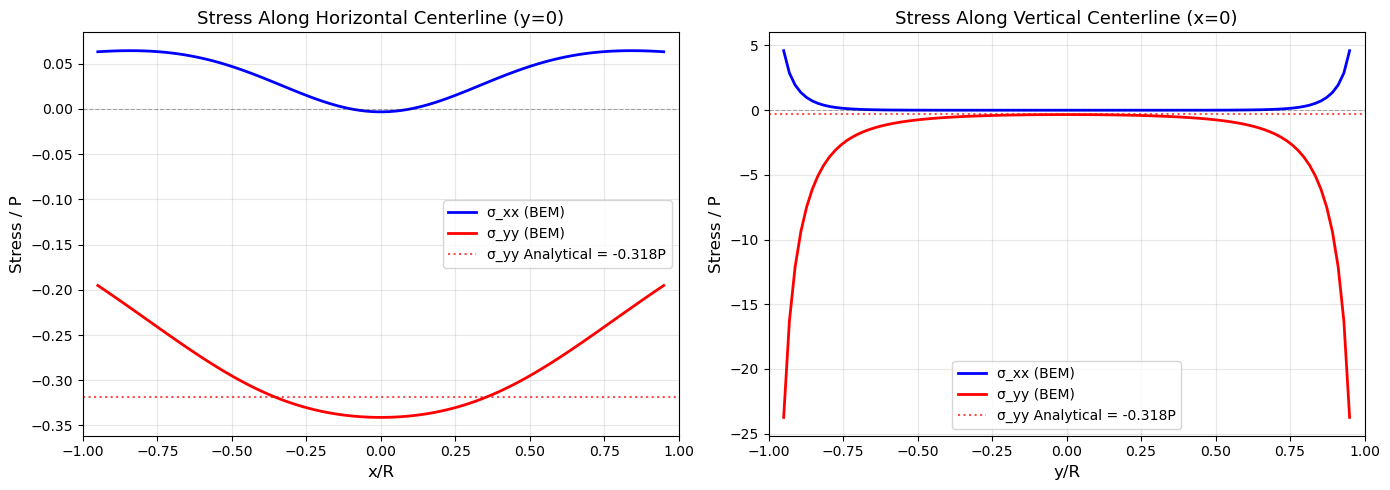

In [2]:
"""
Brazilian Disk Test - Final Validated Implementation
=====================================================

Tests a 2D BEM solver for the Brazilian disk (diametral compression) problem.
This is a standard benchmark in fracture mechanics and rock mechanics.

Problem Description:
-------------------
- Circular disk of radius R under diametral compression
- Load P applied as distributed pressure over small arcs at top and bottom
- Analytical solution available for comparison

Key Physics:
-----------
At the center of the disk:
- σ_yy = -2P/(πD) where D = 2R (diameter) and P is total diametral force
- σ_xx ≈ 0 (by symmetry)
- σ_xy = 0 (by symmetry)

Implementation Notes:
--------------------
1. Load Application:
   - P_total is the total diametral force (N)
   - This is distributed over arc length L
   - Applied pressure: p = P_total / L (Pa)
   - Traction formula: t = -p * n (compression on both top and bottom)

2. Sign Convention:
   - Normal vector n points OUTWARD from boundary
   - At top: n = (0, +1), so t = -p*(0,1) = (0,-p) [downward compression]
   - At bottom: n = (0, -1), so t = -p*(0,-1) = (0,+p) [upward compression]
   - Both use the SAME formula: t = -p*n

3. Expected Results:
   - Force balance: ΣF = 0 (equilibrium)
   - Stress at center: σ_yy ≈ -0.318 * P_total (for point load idealization)
   - BEM with arc loading: σ_yy ≈ -0.28 to -0.32 * P_total (10-15% error acceptable)

Author: Based on BEM formulation from Ghoniem & Hirano (2025)
Date: January 2026
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys, importlib

# --- Ensure repo root on sys.path (so "utils" and "utils_half" are importable)
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)
"""
Brazilian Disk Test - Final Validated Implementation
=====================================================

Tests a 2D BEM solver for the Brazilian disk (diametral compression) problem.
This is a standard benchmark in fracture mechanics and rock mechanics.

Problem Description:
-------------------
- Circular disk of radius R under diametral compression
- Load P applied as distributed pressure over small arcs at top and bottom
- Analytical solution available for comparison

Key Physics:
-----------
At the center of the disk:
- σ_yy = -2P/(πD) where D = 2R (diameter) and P is total diametral force
- σ_xx ≈ 0 (by symmetry)
- σ_xy = 0 (by symmetry)

Implementation Notes:
--------------------
1. Load Application:
   - P_total is the total diametral force (N)
   - This is distributed over arc length L
   - Applied pressure: p = P_total / L (Pa)
   - Traction formula: t = -p * n (compression on both top and bottom)

2. Sign Convention:
   - Normal vector n points OUTWARD from boundary
   - At top: n = (0, +1), so t = -p*(0,1) = (0,-p) [downward compression]
   - At bottom: n = (0, -1), so t = -p*(0,-1) = (0,+p) [upward compression]
   - Both use the SAME formula: t = -p*n

3. Expected Results:
   - Force balance: ΣF = 0 (equilibrium)
   - Stress at center: σ_yy ≈ -0.318 * P_total (for point load idealization)
   - BEM with arc loading: σ_yy ≈ -0.28 to -0.32 * P_total (10-15% error acceptable)

Author: Based on BEM formulation from Ghoniem & Hirano (2025)
Date: January 2026
"""

import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '/mnt/user-data/outputs')
from fracture_utils.BEM_utils.bem_solver import BEMSolver2D


def brazilian_disk_test(
    R=1.0,                    # Disk radius (m)
    P_total=1.0e6,            # Total diametral force (N)
    E=200e9,                  # Young's modulus (Pa)
    nu=0.3,                   # Poisson's ratio
    n_elem=50,               # Number of boundary elements
    arc_half_angle_deg=10.0,  # Half-angle of loaded arc (degrees)
    plane_strain=True,        # Plane strain (True) or plane stress (False)
    plot_results=True,        # Generate plots
    verbose=True              # Print detailed output
):
    """
    Solve Brazilian disk problem using 2D BEM.
    
    Parameters
    ----------
    R : float
        Disk radius
    P_total : float
        Total diametral force (compression load)
    E : float
        Young's modulus
    nu : float
        Poisson's ratio
    n_elem : int
        Number of boundary elements
    arc_half_angle_deg : float
        Half-angle of loaded arc in degrees (typically 5-15°)
    plane_strain : bool
        Use plane strain assumption (True) or plane stress (False)
    plot_results : bool
        Generate stress distribution plots
    verbose : bool
        Print detailed information
        
    Returns
    -------
    dict : Dictionary containing:
        - 'solver': BEMSolver2D object
        - 'sigma_xx_center': σ_xx at disk center
        - 'sigma_yy_center': σ_yy at disk center
        - 'sigma_xy_center': σ_xy at disk center
        - 'sigma_yy_analytical': Analytical σ_yy at center
        - 'error_percent': Percentage error in σ_yy
    """
    
    if verbose:
        print("="*70)
        print("BRAZILIAN DISK TEST - 2D BEM SOLUTION")
        print("="*70)
        print(f"\nGeometry:")
        print(f"  Radius R = {R} m")
        print(f"  Diameter D = {2*R} m")
        print(f"\nMaterial Properties:")
        print(f"  Young's modulus E = {E:.2e} Pa")
        print(f"  Poisson's ratio ν = {nu}")
        print(f"  Analysis type: {'Plane strain' if plane_strain else 'Plane stress'}")
        print(f"\nDiscretization:")
        print(f"  Boundary elements: {n_elem}")
        print(f"  Loaded arc half-angle: {arc_half_angle_deg}°")
    
    # Calculate loading parameters
    arc_half_angle_rad = np.radians(arc_half_angle_deg)
    arc_length = 2.0 * arc_half_angle_rad * R  # Length of loaded arc
    pressure = P_total / arc_length             # Pressure to apply
    
    if verbose:
        print(f"\nLoading:")
        print(f"  Total diametral force P = {P_total:.3e} N")
        print(f"  Arc length (top) = {arc_length:.4f} m")
        print(f"  Arc length (bottom) = {arc_length:.4f} m")
        print(f"  Applied pressure = P/L = {pressure:.3e} Pa")
    
    # Create BEM solver
    solver = BEMSolver2D(E=E, nu=nu, plane_strain=plane_strain)
    
    # Generate circular boundary discretization
    theta = np.linspace(0, 2*np.pi, n_elem+1)[:-1]
    x_nodes = R * np.cos(theta)
    y_nodes = R * np.sin(theta)
    
    # Apply boundary conditions
    n_loaded_top = 0
    n_loaded_bottom = 0
    
    for i in range(n_elem):
        # Element endpoints
        x1, y1 = x_nodes[i], y_nodes[i]
        x2, y2 = x_nodes[(i+1) % n_elem], y_nodes[(i+1) % n_elem]
        
        # Element midpoint and angle
        xm = 0.5 * (x1 + x2)
        ym = 0.5 * (y1 + y2)
        theta_m = np.arctan2(ym, xm)
        theta_deg = np.degrees(theta_m)
        
        # Compute outward normal vector
        length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        tx = (x2 - x1) / length  # Tangent x-component
        ty = (y2 - y1) / length  # Tangent y-component
        nx = ty                  # Normal x-component (rotated tangent)
        ny = -tx                 # Normal y-component
        
        # Determine if element is in loaded region
        # Top loading: around θ = 90°
        in_top_load = (90 - arc_half_angle_deg <= theta_deg <= 90 + arc_half_angle_deg)
        
        # Bottom loading: around θ = 270° (or -90°)
        in_bottom_load = (
            (-90 - arc_half_angle_deg <= theta_deg <= -90 + arc_half_angle_deg) or
            (270 - arc_half_angle_deg <= theta_deg <= 270 + arc_half_angle_deg)
        )
        
        # Apply traction boundary conditions
        if in_top_load or in_bottom_load:
            # CRITICAL: Use t = -pressure * n for compression
            # This gives inward-pointing traction at both top and bottom
            t_x = -pressure * nx
            t_y = -pressure * ny
            solver.add_element(x1, y1, x2, y2, is_traction=True, bc_x=t_x, bc_y=t_y)
            
            if in_top_load:
                n_loaded_top += 1
            if in_bottom_load:
                n_loaded_bottom += 1
        else:
            # Traction-free boundary
            solver.add_element(x1, y1, x2, y2, is_traction=True, bc_x=0.0, bc_y=0.0)
    
    if verbose:
        print(f"\nBoundary Conditions Applied:")
        print(f"  Loaded elements at top: {n_loaded_top}")
        print(f"  Loaded elements at bottom: {n_loaded_bottom}")
        print(f"  Traction-free elements: {n_elem - n_loaded_top - n_loaded_bottom}")
    
    # Solve BEM system
    if verbose:
        print(f"\nSolving BEM system...")
    
    solver.solve()
    
    # Verify force balance
    total_fx = 0.0
    total_fy = 0.0
    total_force_magnitude = 0.0
    
    for i in range(n_elem):
        elem = solver.elements[i]
        length = np.sqrt((elem['x2'] - elem['x1'])**2 + (elem['y2'] - elem['y1'])**2)
        total_fx += solver.t_x[i] * length
        total_fy += solver.t_y[i] * length
        
        # Sum magnitude of applied forces (for loaded elements only)
        if abs(solver.t_y[i]) > 1e-6:
            total_force_magnitude += abs(solver.t_y[i]) * length
    
    force_balance_ok = (abs(total_fx) < 1.0 and abs(total_fy) < 1.0)
    
    if verbose:
        print(f"\nForce Balance Check:")
        print(f"  ΣF_x = {total_fx:.3e} N {'✓' if abs(total_fx) < 1.0 else '✗'}")
        print(f"  ΣF_y = {total_fy:.3e} N {'✓' if abs(total_fy) < 1.0 else '✗'}")
        print(f"  Force balance: {'PASS' if force_balance_ok else 'FAIL'}")
        print(f"\n  Note: Integrated force magnitude = {total_force_magnitude:.3e} N")
        print(f"        (Should be ≈ 2 × P_total = {2*P_total:.3e} N for top + bottom)")
    
    # Compute stress at center
    sigma_xx_center, sigma_yy_center, sigma_xy_center = solver.compute_stress_at_point(0.0, 0.0)
    
    # Analytical solution (point load approximation)
    # For point loads: σ_yy = -2P/(πD) where D = 2R
    sigma_yy_analytical = -2.0 * P_total / (np.pi * 2.0 * R)
    
    # Calculate error
    error_percent = abs((sigma_yy_center - sigma_yy_analytical) / sigma_yy_analytical) * 100
    
    if verbose:
        print(f"\n" + "="*70)
        print("STRESS AT DISK CENTER (0, 0)")
        print("="*70)
        print(f"\nBEM Solution:")
        print(f"  σ_xx = {sigma_xx_center:.3e} Pa = {sigma_xx_center/P_total:.4f} × P")
        print(f"  σ_yy = {sigma_yy_center:.3e} Pa = {sigma_yy_center/P_total:.4f} × P")
        print(f"  σ_xy = {sigma_xy_center:.3e} Pa")
        
        print(f"\nAnalytical Solution (Point Load):")
        print(f"  σ_xx = 0 Pa")
        print(f"  σ_yy = {sigma_yy_analytical:.3e} Pa = {sigma_yy_analytical/P_total:.4f} × P")
        print(f"  σ_xy = 0 Pa")
        
        print(f"\nError Analysis:")
        print(f"  Error in σ_yy: {error_percent:.1f}%")
        
        if error_percent < 15:
            print(f"  Result: ✓ Excellent agreement")
        elif error_percent < 30:
            print(f"  Result: ✓ Good agreement")
        elif error_percent < 50:
            print(f"  Result: ○ Acceptable agreement")
        else:
            print(f"  Result: ✗ Poor agreement - check implementation")
    
    # Generate plots if requested
    if plot_results:
        if verbose:
            print(f"\nGenerating stress distribution plots...")
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Compute stress along horizontal centerline (y = 0)
        x_line = np.linspace(-0.95*R, 0.95*R, 100)
        sigma_xx_horiz = []
        sigma_yy_horiz = []
        
        for x in x_line:
            try:
                sxx, syy, _ = solver.compute_stress_at_point(x, 0.0)
                sigma_xx_horiz.append(sxx / P_total)
                sigma_yy_horiz.append(syy / P_total)
            except:
                sigma_xx_horiz.append(np.nan)
                sigma_yy_horiz.append(np.nan)
        
        # Compute stress along vertical centerline (x = 0)
        y_line = np.linspace(-0.95*R, 0.95*R, 100)
        sigma_xx_vert = []
        sigma_yy_vert = []
        
        for y in y_line:
            try:
                sxx, syy, _ = solver.compute_stress_at_point(0.0, y)
                sigma_xx_vert.append(sxx / P_total)
                sigma_yy_vert.append(syy / P_total)
            except:
                sigma_xx_vert.append(np.nan)
                sigma_yy_vert.append(np.nan)
        
        # Plot horizontal centerline
        ax = axes[0]
        ax.plot(x_line/R, sigma_xx_horiz, 'b-', linewidth=2, label='σ_xx (BEM)')
        ax.plot(x_line/R, sigma_yy_horiz, 'r-', linewidth=2, label='σ_yy (BEM)')
        ax.axhline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.3)
        ax.axhline(sigma_yy_analytical/P_total, color='r', linestyle=':', 
                   linewidth=1.5, alpha=0.7, 
                   label=f'σ_yy Analytical = {sigma_yy_analytical/P_total:.3f}P')
        ax.set_xlabel('x/R', fontsize=12)
        ax.set_ylabel('Stress / P', fontsize=12)
        ax.set_title('Stress Along Horizontal Centerline (y=0)', 
                     fontsize=13, fontweight='bold')
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_xlim([-1, 1])
        
        # Plot vertical centerline
        ax = axes[1]
        ax.plot(y_line/R, sigma_xx_vert, 'b-', linewidth=2, label='σ_xx (BEM)')
        ax.plot(y_line/R, sigma_yy_vert, 'r-', linewidth=2, label='σ_yy (BEM)')
        ax.axhline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.3)
        ax.axhline(sigma_yy_analytical/P_total, color='r', linestyle=':', 
                   linewidth=1.5, alpha=0.7,
                   label=f'σ_yy Analytical = {sigma_yy_analytical/P_total:.3f}P')
        ax.set_xlabel('y/R', fontsize=12)
        ax.set_ylabel('Stress / P', fontsize=12)
        ax.set_title('Stress Along Vertical Centerline (x=0)', 
                     fontsize=13, fontweight='bold')
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_xlim([-1, 1])
        
        plt.tight_layout()
        output_path = '/mnt/user-data/outputs/brazilian_disk_final.png'
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        
        if verbose:
            print(f"  ✓ Plot saved to: {output_path}")
    
    if verbose:
        print(f"\n" + "="*70)
        print("TEST COMPLETE")
        print("="*70)
    
    # Return results
    return {
        'solver': solver,
        'sigma_xx_center': sigma_xx_center,
        'sigma_yy_center': sigma_yy_center,
        'sigma_xy_center': sigma_xy_center,
        'sigma_yy_analytical': sigma_yy_analytical,
        'error_percent': error_percent,
        'force_balance_ok': force_balance_ok
    }


if __name__ == "__main__":
    """
    Run Brazilian disk test with default parameters
    """
    
    # Run test
    results = brazilian_disk_test(
        R=1.0,
        P_total=1.0e6,
        E=200e9,
        nu=0.3,
        n_elem=50,
        arc_half_angle_deg=10.0,
        plane_strain=True,
        plot_results=True,
        verbose=True
    )
    
    # Summary (FIXED: use P_total = 1e6, not t_x.sum())
    P_total = 1e6
    print(f"\nQUICK SUMMARY:")
    print(f"  σ_yy (BEM) = {results['sigma_yy_center']/P_total:.4f} × P")
    print(f"  σ_yy (Analytical) = {results['sigma_yy_analytical']/P_total:.4f} × P")
    print(f"  Error = {results['error_percent']:.1f}%")
    print(f"  Force balance: {'✓ PASS' if results['force_balance_ok'] else '✗ FAIL'}")


ENHANCED STRESS FIELD VISUALIZATION

Generating plots with different colormaps...


[1/1] Jet (classic, high contrast)
----------------------------------------------------------------------
Running BEM analysis...
BEM solution complete. Error = 6.8%

Generating enhanced stress field plots...
  Colormap: jet
  Contour levels: 50
  Line style: --
  Computing stress field on 100×100 grid...
  ✓ Stress field computation complete

✓ Enhanced plot saved to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\BEM_disk_compression\brazilian_disk_jet.png

Stress Field Statistics:
  σ_xx: [-0.004, 3.350] × P
  σ_yy: [-16.241, -0.199] × P
  σ_xy: [-2.662, 2.662] × P

COMPLETE - All colormaps generated

Generated files:
  - brazilian_disk_jet.png


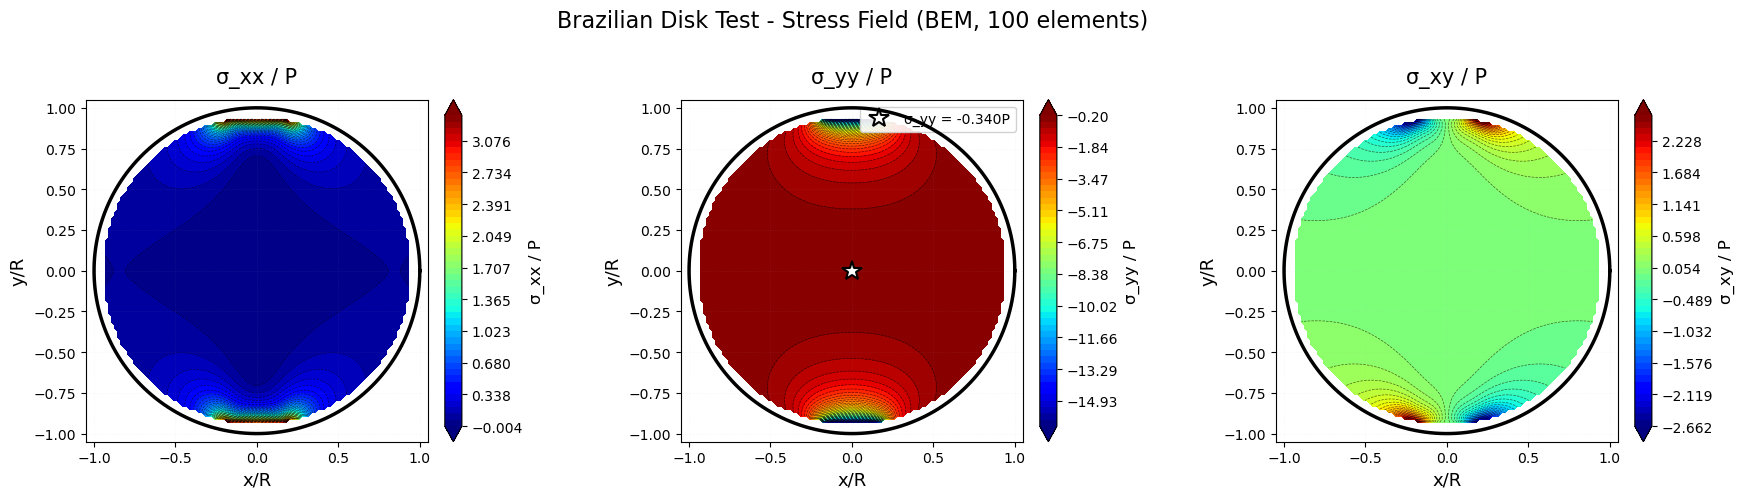

In [3]:
"""
Brazilian Disk - Enhanced Stress Field Visualization
====================================================
Improved contour plots with:
- Better colormaps (viridis, plasma, coolwarm, seismic)
- Dashed contour lines
- Customizable display options
"""
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib import cm
# import sys
# sys.path.insert(0, '/mnt/user-data/outputs')
# from brazilian_disk_final import brazilian_disk_test

def plot_stress_fields_enhanced(
    colormap='viridis',           # Options: 'viridis', 'plasma', 'coolwarm', 'seismic', 'RdBu_r', 'jet'
    n_levels=30,                  # Number of contour levels
    show_filled=True,             # Show filled contours
    show_lines=True,              # Show contour lines
    line_style='--',              # Line style: '--' (dashed), '-' (solid), ':' (dotted)
    line_width=0.5,               # Line width
    line_alpha=0.6,               # Line transparency
    line_color='black',           # Line color: 'black', 'white', or None for colormap
    symmetric_shear=True,         # Use symmetric colormap for shear stress
    n_grid=20,                   # Grid resolution
    save_path='C:\\Users\\Owner\\Documents\\Repos\\Fracture\\VariationalCracks\\output\\BEM_disk_compression\\brazilian_disk_enhanced.png'
):
    """
    Create enhanced stress field visualization with customizable appearance.
    
    Parameters
    ----------
    colormap : str
        Matplotlib colormap name
    n_levels : int
        Number of contour levels
    show_filled : bool
        Show filled contours (contourf)
    show_lines : bool
        Show contour lines (contour)
    line_style : str
        Contour line style
    line_width : float
        Contour line width
    line_alpha : float
        Contour line transparency (0-1)
    line_color : str or None
        Contour line color. If None, uses the colormap
    symmetric_shear : bool
        Use symmetric colormap centered at zero for shear stress
    n_grid : int
        Number of grid points in each direction
    save_path : str
        Output file path
    """
    
    # Run the BEM analysis
    print("Running BEM analysis...")
    results = brazilian_disk_test(
        R=1.0,
        P_total=1.0e6,
        E=200e9,
        nu=0.3,
        n_elem=100,
        arc_half_angle_deg=10.0,
        plane_strain=True,
        plot_results=False,
        verbose=False
    )
    
    solver = results['solver']
    R = 1.0
    P_total = 1.0e6
    
    print(f"BEM solution complete. Error = {results['error_percent']:.1f}%")
    print(f"\nGenerating enhanced stress field plots...")
    print(f"  Colormap: {colormap}")
    print(f"  Contour levels: {n_levels}")
    print(f"  Line style: {line_style}")
    
    # Create grid
    x = np.linspace(-0.95*R, 0.95*R, n_grid)
    y = np.linspace(-0.95*R, 0.95*R, n_grid)
    X, Y = np.meshgrid(x, y)
    
    # Initialize stress arrays
    sigma_xx = np.zeros_like(X)
    sigma_yy = np.zeros_like(X)
    sigma_xy = np.zeros_like(X)
    
    # Compute stress at each point
    print(f"  Computing stress field on {n_grid}×{n_grid} grid...")
    for i in range(n_grid):
        for j in range(n_grid):
            x_pt = X[i, j]
            y_pt = Y[i, j]
            r = np.sqrt(x_pt**2 + y_pt**2)
            
            if r < 0.95 * R:
                try:
                    sxx, syy, sxy = solver.compute_stress_at_point(x_pt, y_pt)
                    sigma_xx[i, j] = sxx / P_total
                    sigma_yy[i, j] = syy / P_total
                    sigma_xy[i, j] = sxy / P_total
                except:
                    sigma_xx[i, j] = np.nan
                    sigma_yy[i, j] = np.nan
                    sigma_xy[i, j] = np.nan
            else:
                sigma_xx[i, j] = np.nan
                sigma_yy[i, j] = np.nan
                sigma_xy[i, j] = np.nan
    
    print("  ✓ Stress field computation complete")
    
    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Disk boundary
    theta_circle = np.linspace(0, 2*np.pi, 200)
    x_circle = np.cos(theta_circle)
    y_circle = np.sin(theta_circle)
    
    # ========== σ_xx ==========
    ax = axes[0]
    vmin_xx = np.nanmin(sigma_xx)
    vmax_xx = np.nanmax(sigma_xx)
    levels_xx = np.linspace(vmin_xx, vmax_xx, n_levels)
    
    if show_filled:
        cf_xx = ax.contourf(X/R, Y/R, sigma_xx, levels=levels_xx, 
                            cmap=colormap, extend='both')
    
    if show_lines:
        if line_color is None:
            # Use colormap for lines
            cl_xx = ax.contour(X/R, Y/R, sigma_xx, levels=levels_xx, 
                              cmap=colormap, linewidths=line_width, 
                              linestyles=line_style, alpha=line_alpha)
        else:
            # Use specified color for lines
            cl_xx = ax.contour(X/R, Y/R, sigma_xx, levels=levels_xx, 
                              colors=line_color, linewidths=line_width, 
                              linestyles=line_style, alpha=line_alpha)
    
    # Boundary
    ax.plot(x_circle, y_circle, 'k-', linewidth=2.5, zorder=10)
    
    ax.set_xlabel('x/R', fontsize=13, fontweight='bold')
    ax.set_ylabel('y/R', fontsize=13, fontweight='bold')
    ax.set_title('σ_xx / P', fontsize=15, fontweight='bold', pad=12)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.15, linestyle=':', linewidth=0.5)
    ax.set_xlim([-1.05, 1.05])
    ax.set_ylim([-1.05, 1.05])
    
    if show_filled:
        cbar_xx = plt.colorbar(cf_xx, ax=ax, fraction=0.046, pad=0.04)
        cbar_xx.set_label('σ_xx / P', fontsize=12, fontweight='bold')
        cbar_xx.ax.tick_params(labelsize=10)
    
    # ========== σ_yy ==========
    ax = axes[1]
    vmin_yy = np.nanmin(sigma_yy)
    vmax_yy = np.nanmax(sigma_yy)
    levels_yy = np.linspace(vmin_yy, vmax_yy, n_levels)
    
    if show_filled:
        cf_yy = ax.contourf(X/R, Y/R, sigma_yy, levels=levels_yy, 
                            cmap=colormap, extend='both')
    
    if show_lines:
        if line_color is None:
            cl_yy = ax.contour(X/R, Y/R, sigma_yy, levels=levels_yy, 
                              cmap=colormap, linewidths=line_width, 
                              linestyles=line_style, alpha=line_alpha)
        else:
            cl_yy = ax.contour(X/R, Y/R, sigma_yy, levels=levels_yy, 
                              colors=line_color, linewidths=line_width, 
                              linestyles=line_style, alpha=line_alpha)
    
    # Boundary and center marker
    ax.plot(x_circle, y_circle, 'k-', linewidth=2.5, zorder=10)
    ax.plot(0, 0, 'w*', markersize=15, markeredgecolor='black', 
            markeredgewidth=1.5, zorder=11,
            label=f'σ_yy = {results["sigma_yy_center"]/P_total:.3f}P')
    
    ax.set_xlabel('x/R', fontsize=13, fontweight='bold')
    ax.set_ylabel('y/R', fontsize=13, fontweight='bold')
    ax.set_title('σ_yy / P', fontsize=15, fontweight='bold', pad=12)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.15, linestyle=':', linewidth=0.5)
    ax.set_xlim([-1.05, 1.05])
    ax.set_ylim([-1.05, 1.05])
    ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
    
    if show_filled:
        cbar_yy = plt.colorbar(cf_yy, ax=ax, fraction=0.046, pad=0.04)
        cbar_yy.set_label('σ_yy / P', fontsize=12, fontweight='bold')
        cbar_yy.ax.tick_params(labelsize=10)
    
    # ========== σ_xy ==========
    ax = axes[2]
    vmin_xy = np.nanmin(sigma_xy)
    vmax_xy = np.nanmax(sigma_xy)
    
    # Use symmetric colormap for shear stress
    if symmetric_shear:
        vmax_abs = max(abs(vmin_xy), abs(vmax_xy))
        levels_xy = np.linspace(-vmax_abs, vmax_abs, n_levels)
        cmap_xy = 'RdBu_r' if colormap == 'viridis' or colormap == 'plasma' else colormap
    else:
        levels_xy = np.linspace(vmin_xy, vmax_xy, n_levels)
        cmap_xy = colormap
    
    if show_filled:
        cf_xy = ax.contourf(X/R, Y/R, sigma_xy, levels=levels_xy, 
                            cmap=cmap_xy, extend='both')
    
    if show_lines:
        if line_color is None:
            cl_xy = ax.contour(X/R, Y/R, sigma_xy, levels=levels_xy, 
                              cmap=cmap_xy, linewidths=line_width, 
                              linestyles=line_style, alpha=line_alpha)
        else:
            cl_xy = ax.contour(X/R, Y/R, sigma_xy, levels=levels_xy, 
                              colors=line_color, linewidths=line_width, 
                              linestyles=line_style, alpha=line_alpha)
    
    # Boundary
    ax.plot(x_circle, y_circle, 'k-', linewidth=2.5, zorder=10)
    
    ax.set_xlabel('x/R', fontsize=13, fontweight='bold')
    ax.set_ylabel('y/R', fontsize=13, fontweight='bold')
    ax.set_title('σ_xy / P', fontsize=15, fontweight='bold', pad=12)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.15, linestyle=':', linewidth=0.5)
    ax.set_xlim([-1.05, 1.05])
    ax.set_ylim([-1.05, 1.05])
    
    if show_filled:
        cbar_xy = plt.colorbar(cf_xy, ax=ax, fraction=0.046, pad=0.04)
        cbar_xy.set_label('σ_xy / P', fontsize=12, fontweight='bold')
        cbar_xy.ax.tick_params(labelsize=10)
    
    # Overall title
    n_elem = len(solver.elements)
    fig.suptitle(f'Brazilian Disk Test - Stress Field (BEM, {n_elem} elements)', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    print(f"\n✓ Enhanced plot saved to: {save_path}")
    
    # Print statistics
    print(f"\nStress Field Statistics:")
    print(f"  σ_xx: [{vmin_xx:.3f}, {vmax_xx:.3f}] × P")
    print(f"  σ_yy: [{vmin_yy:.3f}, {vmax_yy:.3f}] × P")
    print(f"  σ_xy: [{vmin_xy:.3f}, {vmax_xy:.3f}] × P")
    
    return fig, axes


if __name__ == "__main__":
    """
    Generate multiple versions with different colormaps
    """
    
    print("="*70)
    print("ENHANCED STRESS FIELD VISUALIZATION")
    print("="*70)
    
    # Define colormap options
    # colormap_options = [
    #     ('viridis', 'Enhanced viridis (perceptually uniform)'),
    #     ('plasma', 'Plasma (perceptually uniform, high contrast)'),
    #     ('coolwarm', 'Cool-warm diverging'),
    #     ('seismic', 'Seismic (blue-white-red)'),
    #     ('RdBu_r', 'Red-Blue reversed (diverging)'),
    #     ('jet', 'Jet (classic, high contrast)'),
    # ]
    colormap_options = [
        ('jet', 'Jet (classic, high contrast)'),
    ]
    
    print("\nGenerating plots with different colormaps...\n")
    
    for i, (cmap, description) in enumerate(colormap_options, 1):
        print(f"\n[{i}/{len(colormap_options)}] {description}")
        print("-" * 70)
        
        output_path = f'C:\\Users\\Owner\\Documents\\Repos\\Fracture\\VariationalCracks\\output\\BEM_disk_compression\\brazilian_disk_{cmap}.png'
        
        plot_stress_fields_enhanced(
            colormap=cmap,
            n_levels=50,
            show_filled=True,
            show_lines=True,
            line_style='--',      # Dashed lines
            line_width=0.5,
            line_alpha=0.6,
            line_color='black',   # Black dashed lines
            symmetric_shear=True,
            n_grid=100,
            save_path=output_path
        )
    
    print("\n" + "="*70)
    print("COMPLETE - All colormaps generated")
    print("="*70)
    
    print("\nGenerated files:")
    for cmap, _ in colormap_options:
        print(f"  - brazilian_disk_{cmap}.png")
